In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})


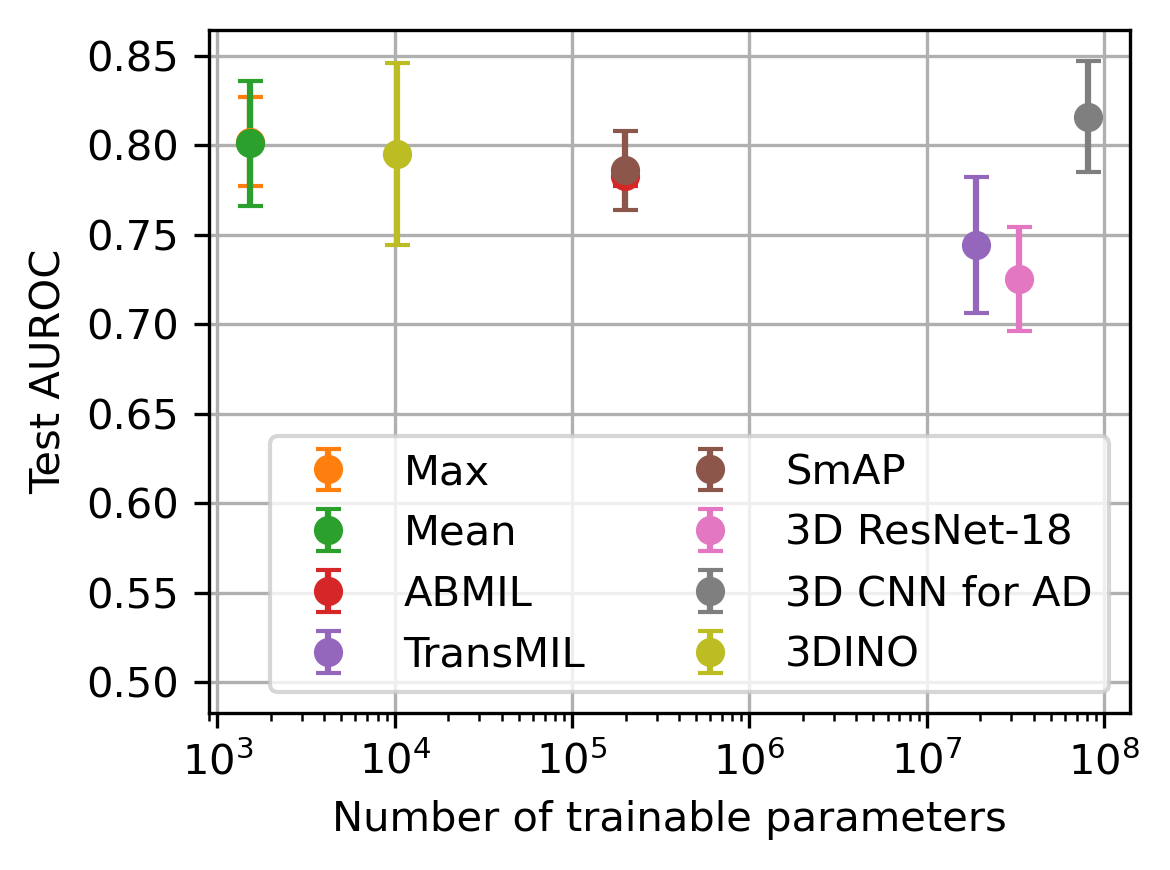

In [3]:
ncols, nrows = 1, 1
fig, ax = plt.subplots(dpi=300, figsize=(4*ncols,3*nrows), ncols=ncols, nrows=nrows)

ax.scatter([1_537], [0.5], color="#FFFFFF")

# OASIS-3 MRI
ax.errorbar(1_537, 0.802, capsize=3, color="#FF7F0E", fmt="o", label="Max", yerr=0.025)
ax.errorbar(1_537, 0.801, capsize=3, color="#2CA02C", fmt="o", label="Mean", yerr=0.035)
ax.errorbar(198_402, 0.783, capsize=3, color="#D62728", fmt="o", label="ABMIL", yerr=0.006)
ax.errorbar(18_923_521, 0.744, capsize=3, color="#9467BD", fmt="o", label="TransMIL", yerr=0.038)
ax.errorbar(198_403, 0.786, capsize=3, color="#8C564B", fmt="o", label="SmAP", yerr=0.022)
ax.errorbar(33_157_377, 0.725, capsize=3, color="#E377C2", fmt="o", label="3D ResNet-18", yerr=0.029)
ax.errorbar(81_420_977, 0.816, capsize=3, color="#7F7F7F", fmt="o", label="3D CNN for AD", yerr=0.031)
ax.errorbar(10_241, 0.795, capsize=3, color="#BCBD22", fmt="o", label="3DINO", yerr=0.051)

ax.set_xlabel("Number of trainable parameters")
ax.set_ylabel("Test AUROC")
ax.set_xscale("log")
ax.legend(ncols=2)
ax.grid()

fig.tight_layout()
fig.savefig("oasis-3_mri_number_of_trainable_parameters.pdf", bbox_inches="tight")
plt.show()


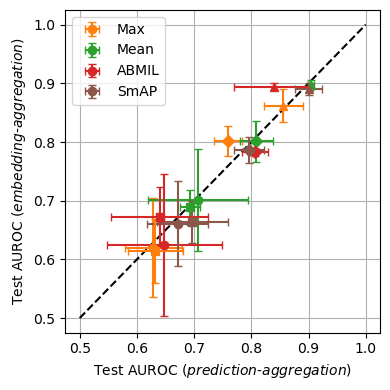

In [20]:
ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols,4*nrows), ncols=ncols, nrows=nrows)

ax.scatter([0.5], [0.5], color="#FFFFFF")

ax.plot([0.5, 1.0], [0.5, 1.0], color="#000000", linestyle="--")

# OASIS-3 CT
ax.errorbar(0.629, 0.620, capsize=3, color="#FF7F0E", fmt="o", label="Max", xerr=0.049, yerr=0.084)
ax.errorbar(0.707, 0.701, capsize=3, color="#2CA02C", fmt="o", label="Mean", xerr=0.088, yerr=0.087)
ax.errorbar(0.648, 0.625, capsize=3, color="#D62728", fmt="o", label="ABMIL", xerr=0.100, yerr=0.121)
ax.errorbar(0.671, 0.661, capsize=3, color="#8C564B", fmt="o", label="SmAP", xerr=0.053, yerr=0.073)
# RSNA-1k CT
ax.errorbar(0.856, 0.862, capsize=3, color="#FF7F0E", fmt="^", xerr=0.034, yerr=0.028)
ax.errorbar(0.904, 0.898, capsize=3, color="#2CA02C", fmt="^", xerr=0.005, yerr=0.008)
ax.errorbar(0.839, 0.894, capsize=3, color="#D62728", fmt="^", xerr=0.069, yerr=0.006)
ax.errorbar(0.900, 0.890, capsize=3, color="#8C564B", fmt="^", xerr=0.023, yerr=0.010)
# ADNI1 MRI
ax.errorbar(0.632, 0.614, capsize=3, color="#FF7F0E", fmt="s", xerr=0.048, yerr=0.054)
ax.errorbar(0.693, 0.689, capsize=3, color="#2CA02C", fmt="s", xerr=0.017, yerr=0.030)
ax.errorbar(0.640, 0.673, capsize=3, color="#D62728", fmt="s", xerr=0.085, yerr=0.050)
ax.errorbar(0.697, 0.664, capsize=3, color="#8C564B", fmt="s", xerr=0.062, yerr=0.036)
# OASIS-3 MRI
ax.errorbar(0.759, 0.802, capsize=3, color="#FF7F0E", fmt="D", xerr=0.024, yerr=0.025)
ax.errorbar(0.809, 0.801, capsize=3, color="#2CA02C", fmt="D", xerr=0.029, yerr=0.035)
ax.errorbar(0.807, 0.783, capsize=3, color="#D62728", fmt="D", xerr=0.023, yerr=0.006)
ax.errorbar(0.796, 0.786, capsize=3, color="#8C564B", fmt="D", xerr=0.026, yerr=0.022)

ax.set_xlabel(r"Test AUROC ($\it{prediction}$-$\it{aggregation}$)")
ax.set_ylabel(r"Test AUROC ($\it{embedding}$-$\it{aggregation}$)")
ax.legend()
ax.grid()

fig.tight_layout()
fig.savefig("architectural_approahces_auroc.pdf", bbox_inches="tight")
plt.show()


In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
import ants
import torch
import torchvision


In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import utils


In [3]:
# 662 CT scans from 495 patients where the patient has a diagnosis at least 80 days before or up to 365
# 657 CT scans from 493 patients where the patient has a diagnosis at least 80 days before or up to 360
nifti_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT'
labels_df = ct.label_oasis3(nifti_dir)
labels_df = labels_df[labels_df["paths"].apply(lambda paths: paths != [""])]
print(labels_df.shape)
print(len(labels_df[["Subject"]].value_counts()))
labels_df.head()


(662, 40)
495


,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths
7,OAS30001_CT_d2438,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,64.0,184.0,NaN,NaN,2699,-261,261,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
21,OAS30001_CT_d3132,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,63.0,185.0,NaN,NaN,3332,-200,200,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
34,OAS30001_CT_d3746,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,64.0,192.0,NaN,NaN,3675,71,71,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
54,OAS30002_CT_d2345,OAS30002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2585,-240,240,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
59,OAS30003_CT_d2669,OAS30003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2630,39,39,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...


In [88]:
labels_df["Alzheimer\'s"].value_counts()

0    556
1    106
Name: Alzheimer's, dtype: int64

In [68]:
labels_df2 = pd.read_csv(f'{numpy_dir}/labels.csv')
labels_df2 = labels_df2.drop(columns=["paths", "path"])
print(labels_df2.shape)
print(len(labels_df2[["Subject"]].value_counts()))
labels_df2.head()


(662, 39)
495


,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,sumbox,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's
0,OAS30001_CT_d2438,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,64.0,184.0,NaN,NaN,2699,-261,261,0
1,OAS30001_CT_d3132,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,63.0,185.0,NaN,NaN,3332,-200,200,0
2,OAS30001_CT_d3746,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,64.0,192.0,NaN,NaN,3675,71,71,0
3,OAS30002_CT_d2345,OAS30002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,2585,-240,240,0
4,OAS30003_CT_d2669,OAS30003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,2630,39,39,0


In [72]:
labels_df1[labels_df1.Subject=="OAS30246"]

,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths
1497,OAS30246_CT_d1591,OAS30246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,62.0,156.0,NaN,NaN,1593,-2,2,0,[]
1509,OAS30246_CT_d2354,OAS30246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,63.0,159.0,NaN,NaN,2317,37,37,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...


In [69]:
diff = labels_df1.merge(labels_df2, how="left", indicator=True)
diff = diff[diff["_merge"] == "left_only"].drop(columns="_merge")
diff

,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,sumbox,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's
152,OAS30246_CT_d1591,OAS30246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,62.0,156.0,NaN,NaN,1593,-2,2,0


In [70]:
diff = labels_df2.merge(labels_df1, how="left", indicator=True)
diff = diff[diff["_merge"] == "left_only"].drop(columns="_merge")
diff

,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,sumbox,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's


(512, 512, 74)


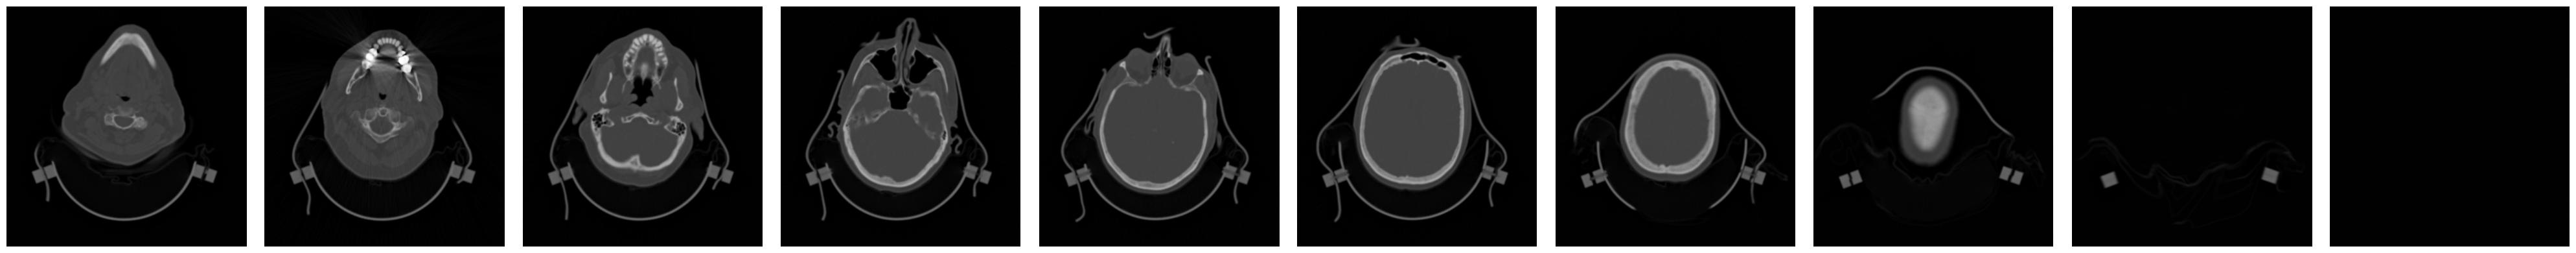

In [32]:
image = ants.image_read(labels_df.iloc[0].paths[0]).numpy()
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()


In [33]:
numpy_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy'
starts = np.linspace(0, 1620, num=11).astype(int)[:-1]
stops = np.linspace(0, 1620, num=11).astype(int)[1:]
for start, stop in zip(starts, stops):
    print(f'    \"python ../src/preprocess_oasis-3_ct.py --nifti_dir=\'{nifti_dir}\' --numpy_dir=\'{numpy_dir}\' --start={start} --stop={stop}\"')
    

    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=0 --stop=162"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=162 --stop=324"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=324 --stop=486"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=486 --stop=648"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=648 --stop=810"
    "python ../src/preprocess_oasis-3_ct.p

In [34]:
labels_df['path'] = labels_df["XNAT_CTSESSIONDATA ID"].apply(lambda ct_id: f"{numpy_dir}/{ct_id}.npz")
#labels_df.to_csv(f'{numpy_dir}/labels.csv', index=False)
labels_df.head()


,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths,path
7,OAS30001_CT_d2438,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.0,184.0,NaN,NaN,2699,-261,261,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
21,OAS30001_CT_d3132,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,63.0,185.0,NaN,NaN,3332,-200,200,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
34,OAS30001_CT_d3746,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.0,192.0,NaN,NaN,3675,71,71,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
54,OAS30002_CT_d2345,OAS30002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2585,-240,240,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
59,OAS30003_CT_d2669,OAS30003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2630,39,39,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...


In [47]:
diff = labels_df.merge(labels_df2, how="left", indicator=True)
diff = diff[diff["_merge"] == "left_only"].drop(columns="_merge")
diff

TypeError: unhashable type: 'list'

In [12]:
np.round(np.linspace(0, 73, num=5)).astype(int)[1:-1]

array([18, 36, 55])

(1, 512, 512, 74)


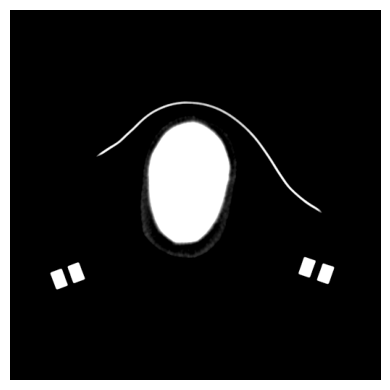

In [16]:
image = np.load(labels_df.iloc[0].path)["arr_0"]
print(image.shape)

fig, ax = plt.subplots(figsize=(4*ncols,4*nrows), ncols=1, nrows=1)

ax.imshow(np.rot90(image[0,:,:,55], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image[0]), vmax=np.max(image[0]))
ax.set_axis_off()
    
fig.tight_layout()
fig.savefig("example_ct_55.pdf", bbox_inches="tight")
plt.show()

In [3]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    #model_name = f'alpha={alpha}_beta=100.0_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    #model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = '--embedding_level ' if embedding_level else ''
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/oasis-3.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'{embedding_level}'
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model_name=\'{model_name}\' '
        f'--pooling=\'{pooling}\' '
        f'{save}'
        f'--seed={seed} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')
    
################################################################################
"""
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, experiments_dir, lr, 
    model, num_channels, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/fine-tune_oasis-3.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model=\'{model}\' '
        f'--model_name=\'{model_name}\' '
        f'--num_channels={num_channels} '
        #f'--pooling=\'{pooling}\' '
        f'{save}'
        f'--seed={seed} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')
"""

'\ndef print_job(\n    alpha, batch_size, criterion, dataset_dir, epochs, experiments_dir, lr, \n    model, num_channels, pooling, save, seed, weight_decay\n):\n    \n    model_name = f\'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}\'\n    \n    if os.path.exists(f\'{experiments_dir}/{model_name}.csv\'):\n        temp_df = pd.read_csv(f\'{experiments_dir}/{model_name}.csv\')\n        if temp_df.shape[0] == epochs:\n            return\n        \n    save = \'--save \' if save else \'\'\n    \n    command = (\n        f\'python ../src/fine-tune_oasis-3.py \'\n        f\'--alpha={alpha} \'\n        f\'--batch_size={batch_size} \'\n        f\'--criterion=\'{criterion}\' \'\n        f\'--dataset_dir=\'{dataset_dir}\' \'\n        f\'--epochs={epochs} \'\n        f\'--experiments_dir=\'{experiments_dir}\' \'\n        f\'--lr={lr} \'\n        f\'--model=\'{model}\' \'\n        f\'--model_name=\'{model_name}\' \'\n        f\'--num_channels={num_channels} \'\n        #f\'--pooling=\'{p

In [10]:
# TODO: 3D ResNet-18
# OASIS-3 CT (seems to be finishing up)
# RSNA Subset CT alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06]
# ADNI1 MRI (seems to be finishing up)
# OASIS-3 MRI Done

# TODO: 3D CNN for AD
# ADNI1 MRI Done
# OASIS-3 MRI Done

In [11]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
#alphas = [0.0]
batch_size = 4
criterions = ['L2']
dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy'
dataset_dir = '/cluster/tufts/hugheslab/datasets/RSNA_numpy'
#dataset_dir = '/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy'
#dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy'
epochs = 100
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_3D_ResNet-18' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA-1k_CT_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_16' 
lrs = [0.1, 0.01, 0.001, 0.0001]
model = "3D ResNet-18"
#model = "ViT-B/16"
num_channels = 1
pooling = "Mean"
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, seed in itertools.product(alphas, criterions, lrs, seeds):

    print_job(alpha, batch_size, criterion, dataset_dir, epochs, 
              experiments_dir, lr, model, num_channels, pooling, save, 
              seed, weight_decay)
    

In [14]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
criterions = ['L2']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = True
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True3' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_163' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Mean']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

times = []

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if "train_sec/epoch" in temp_df.columns:
            times.extend(temp_df["train_sec/epoch"].values)


In [15]:
def format_time(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    seconds = seconds % 60
    return f"{hours} hrs. {minutes} mins. {seconds} secs."

format_time(np.mean(times))

'0.0 hrs. 46.0 mins. 19.11684484915304 secs.'

In [9]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=False'
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL', 'SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)
    

In [12]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=False' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_embedding_level=True' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=1e-05_criterion=L1_lr=0.1_pooling=SmAP_s...,1001,0.791313,0.601047,0.538963,0.599488,0.597942,0.821715,0.624712,0.675217,0.418033,0.416518,0.788941,0.556513,0.525424,0.553644,0.552098
1,alpha=1e-05_criterion=L1_lr=0.1_pooling=SmAP_s...,2001,0.772035,0.541322,0.702898,0.648726,0.644656,0.986532,0.966695,0.923187,0.135953,0.131893,0.815425,0.516614,0.645843,0.584688,0.580618
2,alpha=0.001_criterion=L1_lr=0.001_pooling=SmAP...,3001,0.824234,0.594840,0.657864,0.486613,0.404752,0.873653,0.709001,0.701716,0.447036,0.365197,0.795823,0.608775,0.638221,0.516274,0.434413


In [13]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.796 +/- 0.026
0.579 +/- 0.033


In [6]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L2']
dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy'
dataset_dir = '/cluster/tufts/hugheslab/datasets/RSNA_numpy'
#dataset_dir = '/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy'
#dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_3D_ResNet-18' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA-1k_CT_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_OnTheDesign' 
lrs = [0.1, 0.01, 0.001, 0.0001]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, seed in itertools.product(alphas, criterions, lrs, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.0001_criterion=L2_lr=0.01_seed=1001,1001,0.844886,0.796797,0.746023,1.434016,0.829770,0.951014,0.944086,0.887175,0.889543,0.284869,0.837149,0.755670,0.750281,1.388813,0.784568
1,alpha=0.0_criterion=L2_lr=0.01_seed=2001,2001,0.866364,0.821760,0.813636,0.573272,0.573272,0.888409,0.866474,0.815899,0.461146,0.461146,0.793901,0.751999,0.759954,0.869628,0.869628
2,alpha=0.01_criterion=L2_lr=0.01_seed=3001,3001,0.839077,0.748286,0.737218,0.856707,0.576758,0.847219,0.825942,0.790844,0.756785,0.462806,0.843750,0.797635,0.708523,0.858558,0.578609


In [7]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.850 +/- 0.014
0.789 +/- 0.037


In [12]:
temp_df = pd.read_csv(f"{experiments_dir}/alpha=1.0_criterion=L2_lr=0.001_seed=1001.csv")
print(temp_df.shape)

plt.plot(temp_df.epoch, temp_df.train_auroc)
plt.plot(temp_df.epoch, temp_df.val_auroc)
plt.plot(temp_df.epoch, temp_df.test_auroc)

FileNotFoundError: [Errno 2] No such file or directory: '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_3D_ResNet-18/alpha=1.0_criterion=L2_lr=0.001_seed=1001.csv'

In [50]:
# AUROC

# CT
# Max: 0.629 +/- 0.049
# Mean: 0.707 +/- 0.088
# ABMIL: 0.648 +/- 0.100

# MRI
# Max: 0.759 +/- 0.024
# Mean: 0.809 +/- 0.029
# ABMIL: 0.807 +/- 0.023


In [ ]:
# AUPRC

# CT
# Max: 0.321 +/- 0.134
# Mean: 0.328 +/- 0.077
# ABMIL: 0.348 +/- 0.038

# MRI
# Max: 0.511 +/- 0.082
# Mean: 0.618 +/- 0.078
# ABMIL: 0.596 +/- 0.046


In [9]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
#dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
#dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
#dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ConvNeXt_Tiny'
#dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/MedSAM'
#dataset_dir = '/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_subset/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16'
epochs = 1000
#embedding_level = False
embedding_level = True
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=True' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True' 
# Note: Guided attention for OASIS-3 MRI
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_test' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=ConvNeXt-Tiny' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM_neck=False' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_16' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=False' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL', 'TransMIL', 'SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)


    "python ../src/oasis-3.py --alpha=1.0 --batch_size=64 --criterion='L1' --dataset_dir='/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed=1001' --epochs=1000 --embedding_level --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True' --lr=0.1 --model_name='alpha=1.0_criterion=L1_lr=0.1_pooling=Max_seed=1001' --pooling='Max' --save --seed=1001 --weight_decay=0.0"
    "python ../src/oasis-3.py --alpha=1.0 --batch_size=64 --criterion='L1' --dataset_dir='/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed=2001' --epochs=1000 --embedding_level --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True' --lr=0.1 --model_name='alpha=1.0_criterion=L1_lr=0.1_pooling=Max_seed=2001' --pooling='Max' --save --seed=2001 --weight_decay=0.0"
    "python ../src/oasis-3.py --alpha=1.0 --batch_size=64 --criterion='L1' --dataset_dir='/c

In [16]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = False
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=True' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=ConvNeXt-Tiny' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM_neck=False' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_16'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_16_2'
#experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/GuidedL1_beta=1000.0'
#experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/BayesianABMIL'
experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=False'
#experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_MedSAM'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/Label_Guidance'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_best_possible_attention'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_middle_twelve'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_instance-level_batch_size=4096'
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_sampled'
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['ABMIL']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    #model_name = f'alpha={alpha}_beta=100.0_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    #model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=1e-06_criterion=L1_lr=0.1_pooling=ABMIL_...,1001,0.760341,0.734183,0.726705,1.865484,1.864877,0.985043,0.987363,0.964376,0.129127,0.128521,0.864422,0.838444,0.778844,1.167601,1.166994
1,alpha=0.001_criterion=L1_lr=0.01_pooling=ABMIL...,2001,0.890795,0.878757,0.796023,0.524667,0.436595,0.925384,0.905342,0.858442,0.432831,0.344959,0.892980,0.863170,0.757537,0.571886,0.483813
2,alpha=0.01_criterion=L1_lr=0.01_pooling=ABMIL_...,3001,0.864527,0.845551,0.659741,0.926707,0.729721,0.935722,0.914532,0.869917,0.517358,0.320755,0.917045,0.891788,0.689205,0.921275,0.724289


In [17]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.839 +/- 0.069
0.819 +/- 0.076


In [13]:
df.model_name.values

array(['alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001',
       'alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001',
       'alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001'],
      dtype=object)

In [14]:
'/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_embedding_level=True/alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001.pt'
'/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_embedding_level=True/alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001.pt'
'/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_embedding_level=True/alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001.pt'


'/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_full_dataset_embedding_level=True/alpha=0.0001_beta=100.0_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001.pt'

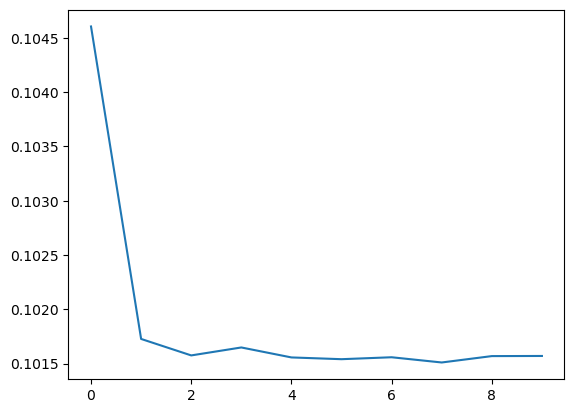

In [94]:
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/Label_Guidance"
model_name = "alpha=0.0_beta=1.0_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=1001"
df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")

plt.plot(df.epoch, df.train_loss)

plt.show()

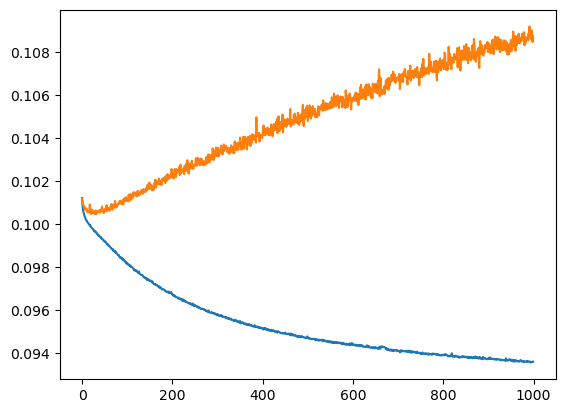

In [96]:
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/Label_Guidance"
model_name = "alpha=0.0_beta=1.0_criterion=GuidedL1_lr=1.0_pooling=ABMIL_seed=1001"
df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")

plt.plot(df.epoch, df.train_loss)
plt.plot(df.epoch, df.val_loss)

plt.show()

In [18]:
print(np.mean([0.5944, 0.5958, 0.5853]), np.std([0.5944, 0.5958, 0.5853]))
print(np.mean([0.8782, 0.8812, 0.8747]), np.std([0.8782, 0.8812, 0.8747]))
print(np.mean([0.7609, 0.7597, 0.7578]), np.std([0.7609, 0.7597, 0.7578]))

0.5918333333333333 0.004654985380093987
0.8780333333333333 0.0026562295750848504
0.7594666666666666 0.0012762793146051073


In [6]:
0.592 0.005
0.878 0.003
0.759 0.001

# AUROC

# CT
# Max: 0.620 +/- 0.084
# Mean: 0.701 +/- 0.087
# ABMIL: 0.625 +/- 0.121
# TransMIL: 0.648 +/- 0.097

# MRI ViT-B/16
# Max: 0.802 +/- 0.025
# Mean: 0.801 +/- 0.035
# ABMIL: 0.783 +/- 0.006
# TransMIL: 0.744 +/- 0.038

# MRI ConvNeXt-Tiny
# Max: 0.789 +/- 0.038
# Mean: 0.788 +/- 0.024
# ABMIL: 0.801 +/- 0.019
# TransMIL: 0.792 +/- 0.032
# SmAP: 0.803 +/- 0.031

# MRI MedSAM
# Max: 0.769 +/- 0.038
# Mean: 0.767 +/- 0.003
# ABMIL: 0.791 +/- 0.031
# TransMIL: 0.775 +/- 0.010
# SmAP: 0.788 +/- 0.025


In [ ]:
# AUPRC

# CT
# Max: 0.303 +/- 0.095
# Mean: 0.347 +/- 0.078
# ABMIL: 0.305 +/- 0.057
# TransMIL: 0.292 +/- 0.061

# MRI ViT-B/16
# Max: 0.562 +/- 0.081
# Mean: 0.613 +/- 0.079
# ABMIL: 0.555 +/- 0.028
# TransMIL: 0.498 +/- 0.085

# MRI ConvNeXt-Tiny
# Max: 0.562 +/- 0.086
# Mean: 0.531 +/- 0.037
# ABMIL: 0.531 +/- 0.037
# TransMIL: 0.571 +/- 0.115
# SmAP: 0.571 +/- 0.074

# MRI MedSAM
# Max: 0.509 +/- 0.102
# Mean: 0.510 +/- 0.013
# ABMIL: 0.547 +/- 0.007
# TransMIL: 0.522 +/- 0.027
# SmAP: 0.522 +/- 0.015
